## MINI PROJET PYTHON SUR DES DONNEES EN ASSSURANCE

##### **NDEYE BAKHOUM** MASTER 1 ECONOMIE DE LA SANTE

L'objectif est de mettre en pratique les différents notions nécessaire pour effectuer un analyse des données. Nous allons
utliser les libraries de base necessaire pour une analyse à savoir **Pandas**, **Numpy** et **Matplotlib**.

In [2]:
# import des librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importation du jeu données

In [3]:
# Import de la base de données

base = pd.read_csv("donnees_assurance.csv", sep = ',')
base.shape

(500, 5)

Pour importer notre base de données, nous avons utiliser la fonction **read_csv()** implantée dans la librairie Pandas. La fonction shape nous permet de connaitre la dimension de notre base qui comprend ici 500 observations et 5 variables.

### Structures des données

In [3]:
# Affichons les dix premiers observations

base.head(10)

,age,sexe,fumeur,nb_accidents,montant_paye
0,57.0,femme,oui,2.0,3133.13
1,64.0,femme,non,1.0,1415.19
2,78.0,homme,non,3.0,3113.89
3,43.0,femme,non,5.0,4551.13
4,55.0,homme,non,5.0,4488.41
5,26.0,homme,non,0.0,695.66
6,47.0,femme,non,NaN,539.16
7,38.0,femme,non,3.0,2830.06
8,31.0,homme,oui,3.0,3847.87
9,51.0,femme,oui,2.0,3115.90


Notre Base de données comprend les variables Age, Sexe("femme" ou "homme"), Fumeur("oui" ou "non"), Nombre d'accidents et  Montant paye des clients.

In [4]:
# Informations sur le types de variables

base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           475 non-null    float64
 1   sexe          491 non-null    object 
 2   fumeur        488 non-null    object 
 3   nb_accidents  472 non-null    float64
 4   montant_paye  500 non-null    float64
dtypes: float64(3), object(2)
memory usage: 19.7+ KB


In [5]:
# Determinons les valeurs manquantes par variables

base.isna().sum()

age             25
sexe             9
fumeur          12
nb_accidents    28
montant_paye     0
dtype: int64

On utilise la fonction **isna()** et **sum()** pour identifier les données manquantes. Nous pouvons constater que certaines de nosvariables présentent des valeurs manquantes. De ce fait avant de commencer tout analyse nous allons exclure les lignes présentant des données manquantes dans notre base.

In [6]:
# Supprimons les données manquantes

base1 = base.dropna()

In [7]:
base1.shape

(433, 5)

Pour supprimer nos valeurs manquantes, nous utilisons la fonction **drop.na()**. Nous passons ainsi d'une base de 500 à 433 observations

### 1 - Répartition des âges des clients

In [8]:
# Déterminons les statistiques decriptives

base1["age"].describe()

count    433.000000
mean      48.404157
std       18.245133
min       18.000000
25%       33.000000
50%       47.000000
75%       64.000000
max       80.000000
Name: age, dtype: float64

Nous utilisons la fonction **describe()** afin de determiner les statistiques descriptives relative à la variable **age**.
Notre base est composée de clients âgés entre 18 et 80 ans. L'âge moyen quant à elle est égale à 48 ans. A noté que 50% de nos clients sont âgés de 47 ans. 

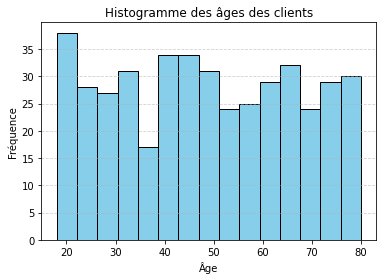

In [9]:
# Tracons lhistogramme des âges

plt.hist(base1["age"], bins=15, color="skyblue", edgecolor="black")
plt.title("Histogramme des âges des clients")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


Pour représenter l'histogramme des âges, nous utilisons la fonction **hist** de la librairie **matplotlib**. La distribution des âges de notre base, nous montre une diversité d'âge au seins de nos clients.

### 2 - Le nombre moyen d'accidents par clients

In [10]:
# La proportion des clients n'ayant aucun accident

prop_sans_accident = base1[base1['nb_accidents'] == 0]

In [11]:
prop_sans_accident.shape

(92, 5)

Dans notre base de données, nous avons 92 clients qui n'ont eu aucun accident.

In [12]:
#  le nombre maximum d'accidents enregistré

Max_nb_accidents = base1['nb_accidents'].max()

In [13]:
Max_nb_accidents

5.0

Le nombre maximum d'accidents enregistré par les assureurs est de 5 accidents

In [14]:
# Vérification des cas anormalement élevés (valeurs atypiques)

nb_outliers = (base1["nb_accidents"] > 5).sum()

In [15]:
nb_outliers

0

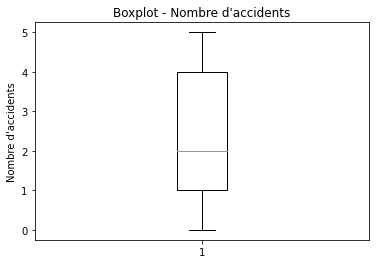

In [16]:
# Autres méthodes pour déterminer les cas anormales : Boxplot

plt.boxplot(base1["nb_accidents"])
plt.title("Boxplot - Nombre d'accidents")
plt.ylabel("Nombre d'accidents")
plt.show()

Pour déterminer les cas anormales ou bien les valeurs abbérantes, nous pouvons:
- Soit fixer un seuil à ne pas dépasser par les valeurs prises par la variables et considerer comme outliers toutes valeurs supérieurs à ce seuil.
- Soit construire le boxplot de la variables. Dans ce cas les points qui apparaissent au delas des extrémités sont considérés comme des outliers.

Dans notre cas npos pouvons déduire que notre variable **nb_accidents** ne présente pas de cas anormales(outliers)

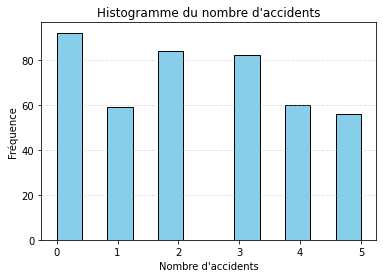

In [17]:
# l'histogramme du nombre d'accidents

plt.hist(base1["nb_accidents"], bins=12, color="skyblue", edgecolor="black")
plt.title("Histogramme du nombre d'accidents")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Nous constatons que le nombre d'accidents varie entre 0 et 5. Le nombre de client n'ayant eu aucun accident est plus élevé 
par rapport au autres. Et le nombre d'accident moyen par client est environ égale à 2.

### 4 - Le montant total payé par l'assureur

In [18]:
# Le montant moyen payé par l'assureur 

montant_moyen_payé = base1['montant_paye'].mean()

In [19]:
montant_moyen_payé

2844.795542725171

In [20]:
# Le montant total cumulé sur tous les clients valides

montant_total_cumulé = base1['montant_paye'].cumsum()

In [21]:
montant_total_cumulé

0         3133.13
1         4548.32
2         7662.21
3        12213.34
4        16701.75
          ...    
494    1218130.21
495    1221256.10
496    1224904.07
498    1227825.62
499    1231796.47
Name: montant_paye, Length: 433, dtype: float64

In [23]:
client_plus_couteux = base1.loc[base1['montant_paye'].idxmax()]

In [24]:
client_plus_couteux

age                80.0
sexe              homme
fumeur              oui
nb_accidents        5.0
montant_paye    5822.36
Name: 331, dtype: object

- Le montant moyen payé par l'assureur aux clients est égale à 2844.79. Pour déterminer le montant moyen nous utilisons la fontion **mean()**.
- Le montant total déboursé par l'assureur afin de payer les clients s'éléve à 1231796.47. La fonction **cumsum()** nous permet de faire le cumul des montants et on obtient à la dernière ligne le montant total cumulé.
- Le client qui à couté le plus à l'assureur est un client âge de 80 ans, de sexe masculin qui est de surcroit fumeur et ayant eu 5 accidents. Il a recu un montant d'indemnité égale à 5822.38. La fonction **idxmax()** nous permet d'avoir l’indice où le montant payé est le plus élevé et **loc[]** nous permet de récupérer toute la ligne du client : âge, sexe, fumeur, nb_accidents, montant_paye.

### 5 - Les catégories de clients qui coutent le plus cher

In [25]:
# Le montant moyen payé selon le sexe

Montant_paye_sexe = base1[["montant_paye","sexe"]].groupby(["sexe"]).mean()

In [26]:
Montant_paye_sexe

,montant_paye
sexe,
femme,2812.280495
homme,2873.228615


- La fonction **groupby()** nous permet d'obtenir le montant moyen par sexe. Nous pouvons noter que le montant moyen d'indemnité versé au hommes est légérement supérieur à celui des femmes.

In [27]:
# Le montant moyen payé selon le fait que le client soit fumeur ou non

Montant_paye_fume = base1[["montant_paye","fumeur"]].groupby(["fumeur"]).mean()

In [28]:
Montant_paye_fume

,montant_paye
fumeur,
non,2467.550000
oui,3268.272157


- Le montant moyen d'indemnité payé par l'assureur au clients qui sont fumeur est largement supérieur à celui payé au non fumeur.

In [29]:
# Creation des différents tranche d'âge

base2 = base1.copy()

tranche = [18, 30, 45, 60, np.inf]
libellé = ['18-30', '31-45', '46-60', '60+']
base2['tranche_age'] = pd.cut(base2['age'], bins=tranche, labels=libellé, right=True)

In [30]:
base2.head(5)

,age,sexe,fumeur,nb_accidents,montant_paye,tranche_age
0,57.0,femme,oui,2.0,3133.13,46-60
1,64.0,femme,non,1.0,1415.19,60+
2,78.0,homme,non,3.0,3113.89,60+
3,43.0,femme,non,5.0,4551.13,31-45
4,55.0,homme,non,5.0,4488.41,46-60


In [31]:
# Le montant moyen payé selon les tranches d'âge

Montant_paye_tra = base2[["montant_paye","tranche_age"]].groupby(["tranche_age"]).mean()

In [32]:
Montant_paye_tra

,montant_paye
tranche_age,
18-30,2844.696829
31-45,2839.773810
46-60,2954.254040
60+,2781.277721


- Afin d'obtenir le montant moyen payé par tranche d'âge, nous commencons d'abord par creer une nouvelle variable qui va regrouper les tranches d'âge et puis utiliser un groupby sur cette variable pour au final avoir le montant moyen par tranche d'âge.
- Nous constatons que les clients qui ont un âge compris entre 46-60 ans recoivent un montant moyen indemnité plus élevé contrairement au plus de 60 ans qui touche un montant moyen plus faible
- Les clients qui coutent plus cher sont donc les hommes, ls fumeurs et ceux ayant un âge compris entre 46-60 ans.

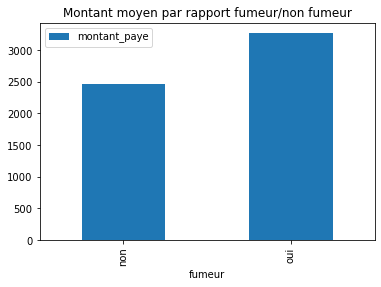

In [33]:
# La variable qui semble le plus corrélées avec le coût

Montant_paye_fume.plot.bar(title = "Montant moyen par rapport fumeur/non fumeur")
plt.show()

On note une grande différence de montant moyen payé par rapport au fait que le client soit fumeur ou non fumeur. On peut
déduire que c'est une variable très influente. 
La variable **fumeur** semble donc plus corrélées au coût

### 6 - Relation entre le nombre d'accidents et le montant payé

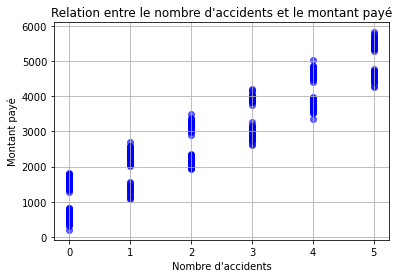

In [34]:
# Nuage des points entre le nombre d'accidents et le montant payé

plt.scatter(base2['nb_accidents'], base2['montant_paye'], alpha=0.6, color='blue')
plt.title("Relation entre le nombre d'accidents et le montant payé")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Montant payé")
plt.grid(True)
plt.show()

La relation entre le nombre d'accidents et le montant payé est mis en évidence par un nuage de points obtenue avec la fonction **scatter()**. Nous notons une forte relation entre le nombre d'accidents et le montant payé

In [35]:
# Coéfficient de corrélation entre le nombre d'accidents et le montant payé

coef_corr = np.corrcoef(base2['nb_accidents'], base2['montant_paye'])

In [36]:
coef_corr

array([[1.        , 0.92932749],
       [0.92932749, 1.        ]])

Le coéfficient de corrélation entre les variables nombre d'accidents et le montant payé est égale à 0.929. Elle est obtenu 
avec la fonction **corrcoef** implanté dans la librairie **numpy**

En obervant le nuage de point entre le nombre d'accident et le montant payé, nous pouvons dire que une tendance linéaire
positive entre ces deux variables. Autrement dit lorsque le nombre d'accidents augmente, le montant payé augmente aussi 
de manière régulière. Le coéfficent de corrélation  le confirme avec un coéfficient trés élevé (proche de 1).


### 6 - Le top 5 clients les plus coûteux

In [37]:
top5_clients = base2.nlargest(5, 'montant_paye')
print(top5_clients)

      age   sexe fumeur  nb_accidents  montant_paye tranche_age
331  80.0  homme    oui           5.0       5822.36         60+
239  68.0  homme    oui           5.0       5769.83         60+
451  66.0  homme    oui           5.0       5757.86         60+
101  75.0  homme    oui           5.0       5696.90         60+
316  50.0  femme    oui           5.0       5676.54       46-60


Nous pouvons ainsi voir que sur les cinq clients les plus coûteux, tous sont des hommes à l'exeption d'une femme. Tous ont un nombre d'accidents égale à 5 et sont des fumeurs et enfin ils sont âgés tous de plus de 50 ans.